In [1]:
from pathlib import Path
from collections import Counter
import csv
import sys

import matplotlib.pyplot as plt

# Locate the project whether the notebook starts in the root
# folder or inside notebooks/.
current = Path.cwd().resolve()

PROJECT_ROOT = next(
    (
        folder
        for folder in [current, *current.parents]
        if (folder / "data" / "splits" / "train.csv").is_file()
    ),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Open the waste-image-classifier project folder in VS Code."
    )

with (PROJECT_ROOT / "data/splits/train.csv").open(
    newline="", encoding="utf-8"
) as file:
    train_rows = list(csv.DictReader(file))

print("Python:", sys.executable)
print("Project:", PROJECT_ROOT)
print("Training images:", len(train_rows))

Python: d:\Desktop\Resume_Projects\waste-image-classifier\.venv\Scripts\python.exe
Project: D:\Desktop\Resume_Projects\waste-image-classifier
Training images: 1764


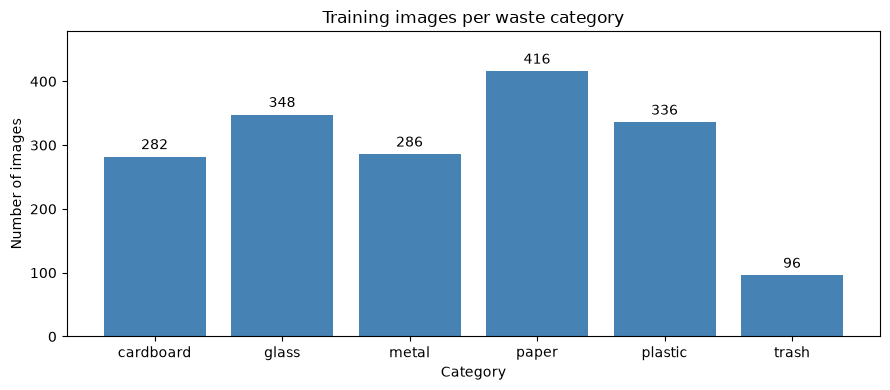

Largest-to-smallest class ratio: 4.33:1


In [2]:
class_names = [
    "cardboard", "glass", "metal", "paper", "plastic", "trash"
]

counts = Counter(row["label"] for row in train_rows)
values = [counts[name] for name in class_names]

fig, ax = plt.subplots(figsize=(9, 4))

bars = ax.bar(class_names, values, color="steelblue")
ax.bar_label(bars, padding=3)
ax.set_title("Training images per waste category")
ax.set_xlabel("Category")
ax.set_ylabel("Number of images")
ax.set_ylim(0, max(values) * 1.15)

plt.tight_layout()
plt.show()

ratio = max(values) / min(values)
print(f"Largest-to-smallest class ratio: {ratio:.2f}:1")

In [3]:
import random
from PIL import Image, ImageOps

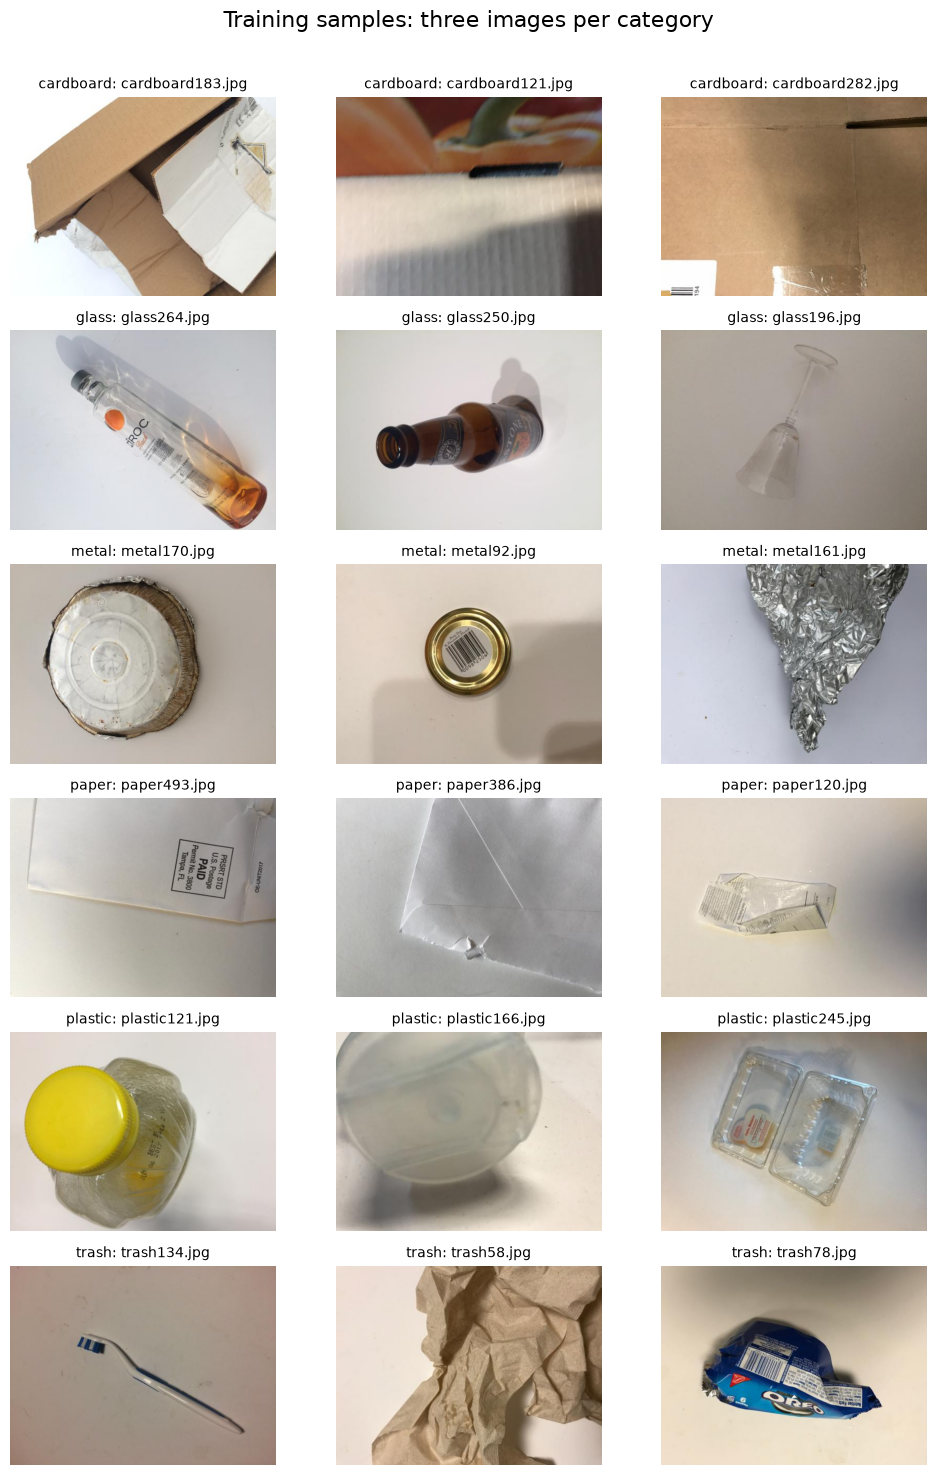

In [4]:
# Fixed seed gives us the same sample when rerunning this cell.
rng = random.Random(42)

fig, axes = plt.subplots(
    nrows=len(class_names),
    ncols=3,
    figsize=(10, 15),
)

for row_index, category in enumerate(class_names):
    # Find training images belonging to this category.
    category_rows = [
        row for row in train_rows
        if row["label"] == category
    ]

    # Select three different images.
    selected = rng.sample(category_rows, 3)

    for column_index, record in enumerate(selected):
        image_path = PROJECT_ROOT / record["path"]

        with Image.open(image_path) as image:
            image = ImageOps.exif_transpose(image).convert("RGB")
            axes[row_index, column_index].imshow(image)

        axes[row_index, column_index].set_title(
            f"{category}: {image_path.name}",
            fontsize=10,
        )
        axes[row_index, column_index].axis("off")

plt.suptitle("Training samples: three images per category", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

### Observations from training samples

- The sampled images vary in object size, orientation, lighting, and shadows.
- Some objects are cropped, blurry, or difficult to distinguish from the background.
- Transparent glass and plastic objects share visual similarities.
- Large background regions may dominate global color histograms.
- The trash category contains visually diverse objects and may overlap
  in appearance with other categories.

These observations are based on 18 training samples, not the entire dataset.
We will inspect validation errors later to see which issues affect the model.

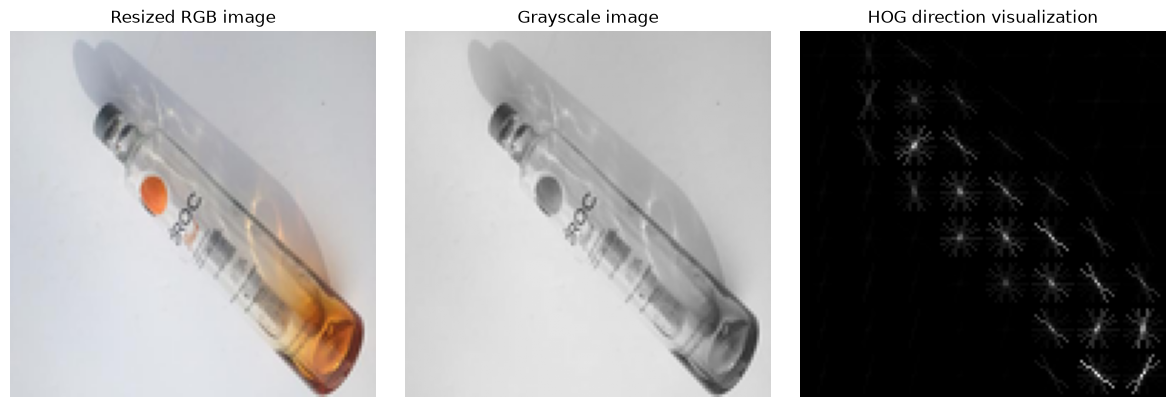

HOG feature count: 1764


In [5]:
import numpy as np
from skimage.color import rgb2gray
from skimage.feature import hog
from skimage import exposure

# Use a glass image from the displayed training samples.
image_path = PROJECT_ROOT / "data/raw/glass/glass264.jpg"

with Image.open(image_path) as image:
    image = ImageOps.exif_transpose(image).convert("RGB")
    image = image.resize((128, 128), Image.Resampling.LANCZOS)
    rgb = np.asarray(image, dtype=np.float32) / 255.0

gray = rgb2gray(rgb)

features, hog_image = hog(
    gray,
    orientations=9,
    pixels_per_cell=(16, 16),
    cells_per_block=(2, 2),
    block_norm="L2-Hys",
    feature_vector=True,
    channel_axis=None,
    visualize=True,
)

# Improve visibility for the plot only; this does not change the features.
hog_display = exposure.rescale_intensity(
    hog_image,
    in_range="image",
    out_range=(0, 1),
)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(rgb)
axes[0].set_title("Resized RGB image")

axes[1].imshow(gray, cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Grayscale image")

axes[2].imshow(hog_display, cmap="gray", vmin=0, vmax=1)
axes[2].set_title("HOG direction visualization")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

print("HOG feature count:", features.size)

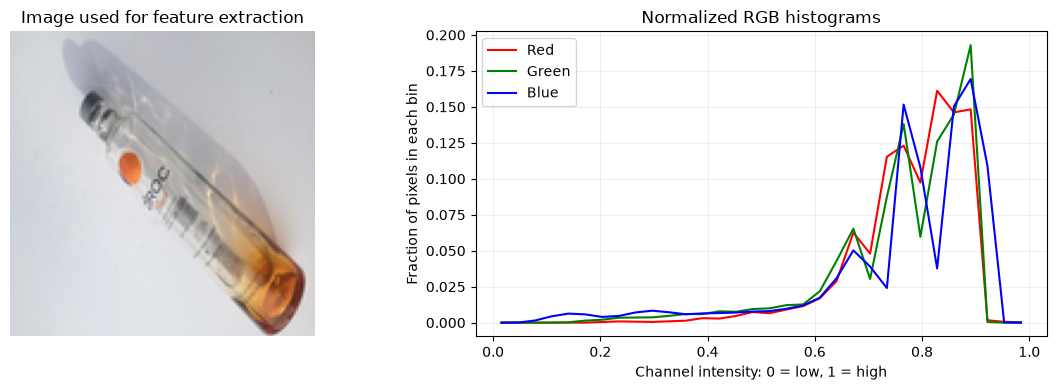

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].imshow(rgb)
axes[0].set_title("Image used for feature extraction")
axes[0].axis("off")

for channel, color in enumerate(["red", "green", "blue"]):
    histogram, bin_edges = np.histogram(
        rgb[:, :, channel],
        bins=32,
        range=(0.0, 1.0),
    )

    # Convert counts into fractions of the image's pixels.
    histogram = histogram.astype(np.float32)
    histogram /= histogram.sum()

    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    axes[1].plot(
        bin_centers,
        histogram,
        color=color,
        label=color.capitalize(),
    )

axes[1].set_title("Normalized RGB histograms")
axes[1].set_xlabel("Channel intensity: 0 = low, 1 = high")
axes[1].set_ylabel("Fraction of pixels in each bin")
axes[1].legend()
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

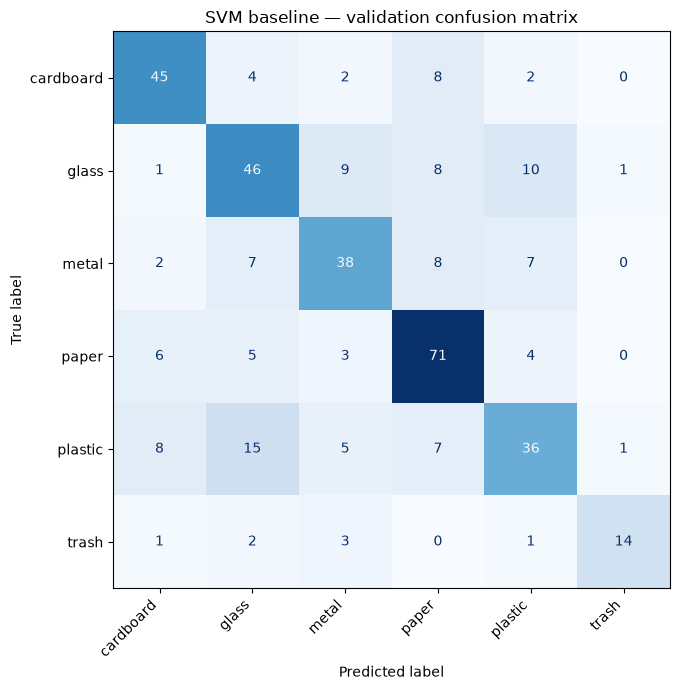

In [7]:
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

metrics_path = PROJECT_ROOT / "reports" / "svm_baseline_metrics.json"

metrics = json.loads(
    metrics_path.read_text(encoding="utf-8")
)

matrix = np.asarray(metrics["validation_confusion_matrix"])
names = metrics["class_names"]

fig, ax = plt.subplots(figsize=(8, 7))

display = ConfusionMatrixDisplay(
    confusion_matrix=matrix,
    display_labels=names,
)

display.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=False,
)

ax.set_title("SVM baseline — validation confusion matrix")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay

# Works when the notebook runs from the project root or notebooks/.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "reports").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent

report_path = PROJECT_ROOT / "reports" / "cnn_scratch_longer_metrics.json"
report = json.loads(report_path.read_text(encoding="utf-8"))

history = report["history"]
epochs = np.arange(1, len(history["loss"]) + 1)
best_epoch = report["best_epoch"]

fig, axes = plt.subplots(1, 3, figsize=(17, 4))

axes[0].plot(epochs, history["accuracy"], label="Training")
axes[0].plot(epochs, history["val_accuracy"], label="Validation")
axes[0].set_title("Accuracy")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(epochs, history["loss"], label="Training")
axes[1].plot(epochs, history["val_loss"], label="Validation")
axes[1].set_title("Loss")
axes[1].set_ylabel("Loss")
axes[1].legend()

axes[2].plot(
    epochs,
    history["val_macro_f1"],
    label="CNN validation macro F1",
)
axes[2].axhline(
    0.7085,
    color="orange",
    linestyle=":",
    label="Tuned SVM: 0.7085",
)
axes[2].set_title("Validation macro F1")
axes[2].set_ylabel("Macro F1")
axes[2].legend()

for ax in axes:
    ax.axvline(
        best_epoch, color="gray", linestyle="--", alpha=0.7
    )
    ax.set_xlabel("Epoch")
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 7))

ConfusionMatrixDisplay(
    confusion_matrix=np.asarray(
        report["validation_confusion_matrix"]
    ),
    display_labels=report["class_names"],
).plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=False,
)

ax.set_title(f"CNN validation confusion matrix — epoch {best_epoch}")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()